<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/29_pca_classification_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA and Classification Comparison

In this notebook, we compare Logistic Regression performance before and after applying Principal Component Analysis (PCA).

Objectives:
- Train Logistic Regression on original features
- Apply PCA for dimensionality reduction
- Train Logistic Regression on PCA-transformed data
- Compare classification performance

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=5,
    random_state=42
)

print("Dataset Shape:", X.shape)

Dataset Shape: (500, 10)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (400, 10)
Testing Shape: (100, 10)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
model_original = LogisticRegression()

model_original.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [6]:
pred_original = model_original.predict(
    X_test_scaled
)

acc_original = accuracy_score(
    y_test,
    pred_original
)

print(
    "Original Accuracy:",
    acc_original
)

Original Accuracy: 0.82


In [7]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

In [8]:
print(
    "Explained Variance Ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "Total Variance Retained:",
    pca.explained_variance_ratio_.sum()
)

Explained Variance Ratio:
[0.28618511 0.15559149]
Total Variance Retained: 0.4417766044220958


In [9]:
model_pca = LogisticRegression()

model_pca.fit(
    X_train_pca,
    y_train
)

LogisticRegression()

In [10]:
pred_pca = model_pca.predict(
    X_test_pca
)

acc_pca = accuracy_score(
    y_test,
    pred_pca
)

print(
    "PCA Accuracy:",
    acc_pca
)

PCA Accuracy: 0.71


In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Original Data",
        "PCA Data"
    ],
    "Accuracy": [
        acc_original,
        acc_pca
    ]
})

comparison

,Model,Accuracy
0,Original Data,0.82
1,PCA Data,0.71


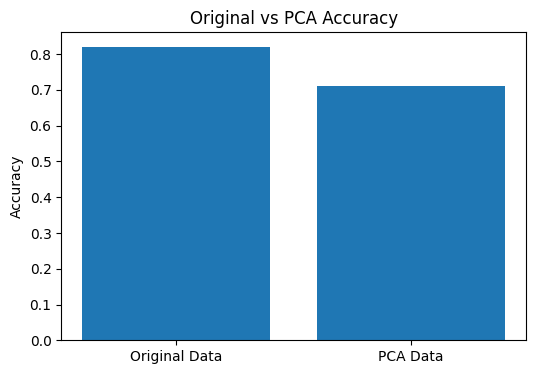

In [12]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Original vs PCA Accuracy"
)

plt.show()

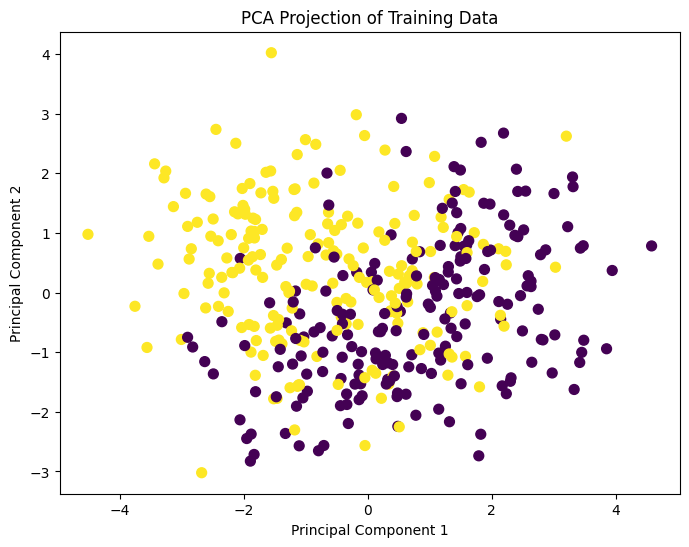

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    s=50
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Projection of Training Data"
)

plt.show()

## Conclusion

This notebook compared Logistic Regression performance before and after PCA.

Observations:
- PCA reduced the feature space from 10 features to 2 principal components.
- Some information was compressed while retaining most variance.
- Classification accuracy was compared on original and PCA-transformed data.
- PCA can reduce complexity while maintaining useful predictive information.